# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [7]:
### Metra Phirielle VANDJY BOUNDZANGA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Charger les données transactions.csv
df = pd.read_csv('transactions.csv')

# Convertir
df['date_time'] = pd.to_datetime(df['date_time'])

# Vérifier les valeurs manquantes
print(df.isnull().sum())  # Pas de valeurs manquantes

# Aperçu des données
print(df.head())


user_id      0
date_time    0
type         0
duration     0
volume_MB    0
region       0
dtype: int64
     user_id           date_time  type  duration  volume_MB    region
0  user_0244 2025-06-23 09:21:00  data         0     462.74  Atakpamé
1  user_0328 2025-01-02 22:16:00  call       154       0.00      Kara
2  user_0335 2025-06-11 22:46:00   sms         0       0.00  Atakpamé
3  user_0249 2025-05-29 02:17:00   sms         0       0.00  Atakpamé
4  user_0287 2025-06-28 06:06:00  call       271       0.00    Tsévié


Colonnes du DataFrame initial : ['user_id', 'date_time', 'type', 'duration', 'volume_MB', 'region']
Valeurs manquantes :
 user_id      0
date_time    0
type         0
duration     0
volume_MB    0
region       0
dtype: int64
Valeurs uniques dans 'type' : ['data' 'call' 'sms']
Colonnes de user_agg après agrégation : ['user_id', 'total_call_duration', 'total_data_volume', 'call_count', 'sms_count', 'data_count']
Aperçu de user_agg :
      user_id  total_call_duration  total_data_volume  call_count  sms_count  \
0  user_0001                  567             516.08           1          1   
1  user_0002                  590            1508.72           3          0   
2  user_0003                  478             348.48           1          3   
3  user_0004                  115             196.97           2          3   
4  user_0005                    0             442.41           0          2   

   data_count  
0           2  
1           5  
2           2  
3           1  
4        

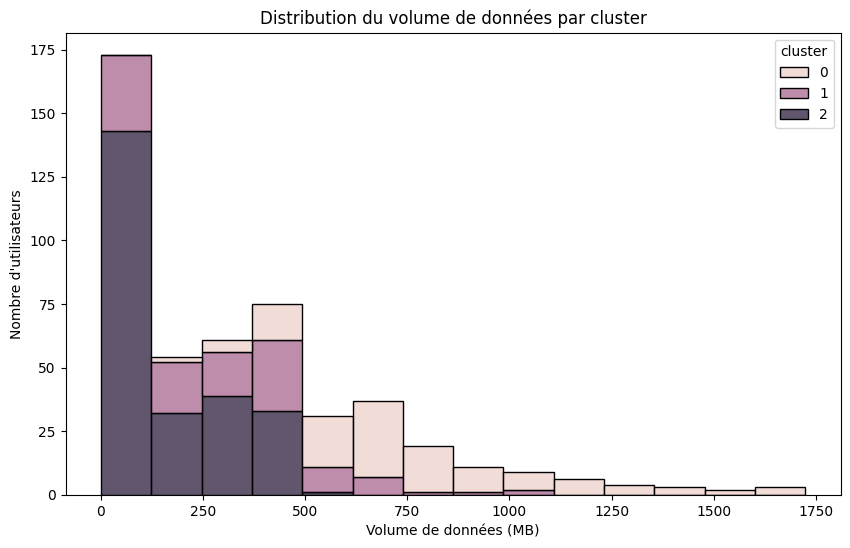

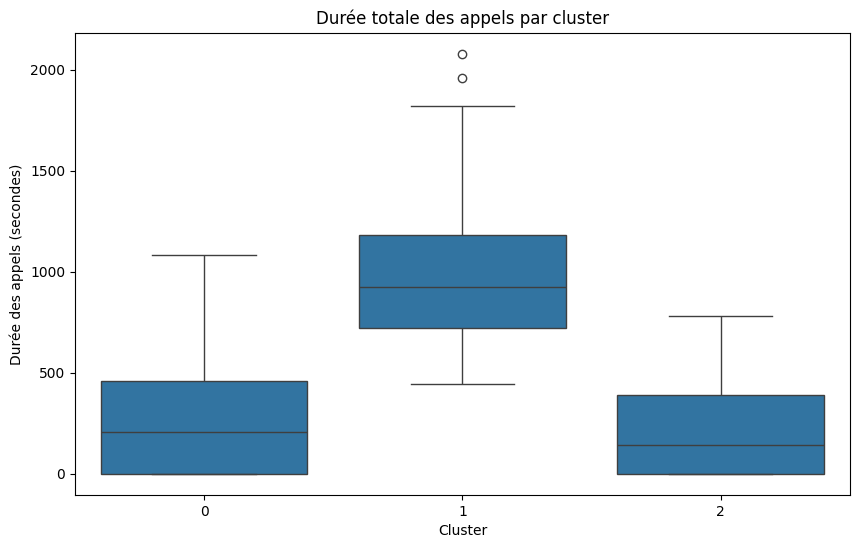

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Étape 1 : Chargement des données
try:
    df = pd.read_csv('transactions.csv')
    print("Colonnes du DataFrame initial :", df.columns.tolist())
except FileNotFoundError:
    print("Erreur : Le fichier 'transactions.csv' n'a pas été trouvé. Vérifiez le chemin du fichier.")
    exit()

# Vérification des colonnes attendues
expected_columns = ['user_id', 'date_time', 'type', 'duration', 'volume_MB', 'region']
missing_columns = [col for col in expected_columns if col not in df.columns]
if missing_columns:
    print(f"Erreur : Les colonnes suivantes sont manquantes dans transactions.csv : {missing_columns}")
    exit()

# Convertir
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

# Vérifier les valeurs manquantes
print("Valeurs manquantes :\n", df.isnull().sum())

# Vérifier les valeurs uniques dans 'type'
print("Valeurs uniques dans 'type' :", df['type'].unique())

# Étape 2 : Agrégation par utilisateur
try:
    user_agg = df.groupby('user_id').agg({
        'duration': 'sum',
        'volume_MB': 'sum',
        'type': [
            lambda x: (x == 'call').sum(),
            lambda x: (x == 'sms').sum(),
            lambda x: (x == 'data').sum()
        ]
    }).reset_index()

    # Renommer les colonnes pour plus de clarté
    user_agg.columns = ['user_id', 'total_call_duration', 'total_data_volume', 'call_count', 'sms_count', 'data_count']
    print("Colonnes de user_agg après agrégation :", user_agg.columns.tolist())
except Exception as e:
    print(f"Erreur lors de l'agrégation : {e}")
    print("Vérifiez la colonne 'type' et assurez-vous qu'elle contient 'call', 'sms', et 'data'.")
    exit()

# Vérifier les données agrégées
print("Aperçu de user_agg :\n", user_agg.head())

# Étape 3 : Clustering avec K-means
features = ['call_count', 'sms_count', 'data_count', 'total_call_duration', 'total_data_volume']
missing_features = [f for f in features if f not in user_agg.columns]
if missing_features:
    print(f"Erreur : Les colonnes suivantes sont manquantes dans user_agg : {missing_features}")
    exit()

# Sélectionner les caractéristiques
X = user_agg[features]

# Standardiser les données
scaler = StandardScaler()
try:
    X_scaled = scaler.fit_transform(X)
except ValueError as e:
    print(f"Erreur lors de la standardisation : {e}")
    print("Vérifiez que les colonnes dans 'features' contiennent des données numériques valides.")
    exit()

# Appliquer K-means
kmeans = KMeans(n_clusters=3, random_state=42)
user_agg['cluster'] = kmeans.fit_predict(X_scaled)

# Analyser les centroïdes
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
print("Centroids des clusters :\n", centroids_df)

# Compter les utilisateurs par cluster
print("Nombre d'utilisateurs par cluster :\n", user_agg['cluster'].value_counts())

# Étape 4 : Visualisations
# Histogramme des volumes de données par cluster
plt.figure(figsize=(10, 6))
sns.histplot(data=user_agg, x='total_data_volume', hue='cluster', multiple='stack')
plt.title('Distribution du volume de données par cluster')
plt.xlabel('Volume de données (MB)')
plt.ylabel('Nombre d\'utilisateurs')
plt.show()

# Boxplot de la durée des appels par cluster
plt.figure(figsize=(10, 6))
sns.boxplot(data=user_agg, x='cluster', y='total_call_duration')
plt.title('Durée totale des appels par cluster')
plt.xlabel('Cluster')
plt.ylabel('Durée des appels (secondes)')
plt.show()

In [9]:
import pandas as pd

# Charger les données
df = pd.read_csv('transactions.csv')
df['type'] = df['type'].str.lower()

# Vérifier les colonnes
print("Colonnes du DataFrame :", df.columns.tolist())

# Compter les événements par type
event_count = df['type'].value_counts().reset_index()
event_count.columns = ['type', 'event_count']
print("Nombre total d'événements par type :\n", event_count)

Colonnes du DataFrame : ['user_id', 'date_time', 'type', 'duration', 'volume_MB', 'region']
Nombre total d'événements par type :
    type  event_count
0   sms          695
1  data          657
2  call          648


In [10]:
# Filtrer les appels avec durée positive
call_data = df[(df['type'] == 'call') & (df['duration'] > 0)]

# Calculer la durée moyenne
avg_call_duration = call_data['duration'].mean()
print("Durée moyenne des appels :", avg_call_duration)

# Créer un DataFrame pour sauvegarde
avg_call_duration_df = pd.DataFrame({'avg_call_duration': [avg_call_duration]})
print("Durée moyenne des appels (DataFrame) :\n", avg_call_duration_df)


Durée moyenne des appels : 304.1033950617284
Durée moyenne des appels (DataFrame) :
    avg_call_duration
0         304.103395


In [11]:
# Filtrer les sessions de données avec volume positif
data_usage = df[(df['type'] == 'data') & (df['volume_MB'] > 0)]

# Calculer le volume moyen par région
avg_data_volume = data_usage.groupby('region')['volume_MB'].mean().reset_index()
avg_data_volume.columns = ['region', 'avg_data_volume']
print("Volume moyen de données par région :\n", avg_data_volume)

Volume moyen de données par région :
      region  avg_data_volume
0  Atakpamé       260.344375
1   Dapaong       262.468830
2      Kara       245.502800
3   Kpalimé       242.064767
4      Lomé       252.892475
5    Sokodé       222.625119
6    Tsévié       277.410833
